In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv('data_games.csv')

**Информация о датасете:**

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4138 entries, 0 to 4137
Data columns (total 46 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   name                    4138 non-null   str    
 1   total_reviews           4137 non-null   float64
 2   tags                    4138 non-null   str    
 3   released                4019 non-null   str    
 4   rating                  4138 non-null   float64
 5   ratings_count           4138 non-null   int64  
 6   metacritic              1330 non-null   float64
 7   playtime                4138 non-null   int64  
 8   genres                  4123 non-null   str    
 9   screenshots_count       4138 non-null   int64  
 10  reviews_score           1987 non-null   float64
 11  price_usd               4138 non-null   float64
 12  positive_ratio          4137 non-null   float64
 13  release_year            4019 non-null   float64
 14  description_word_count  4127 non-null   float64
 15

# Популярность жанров

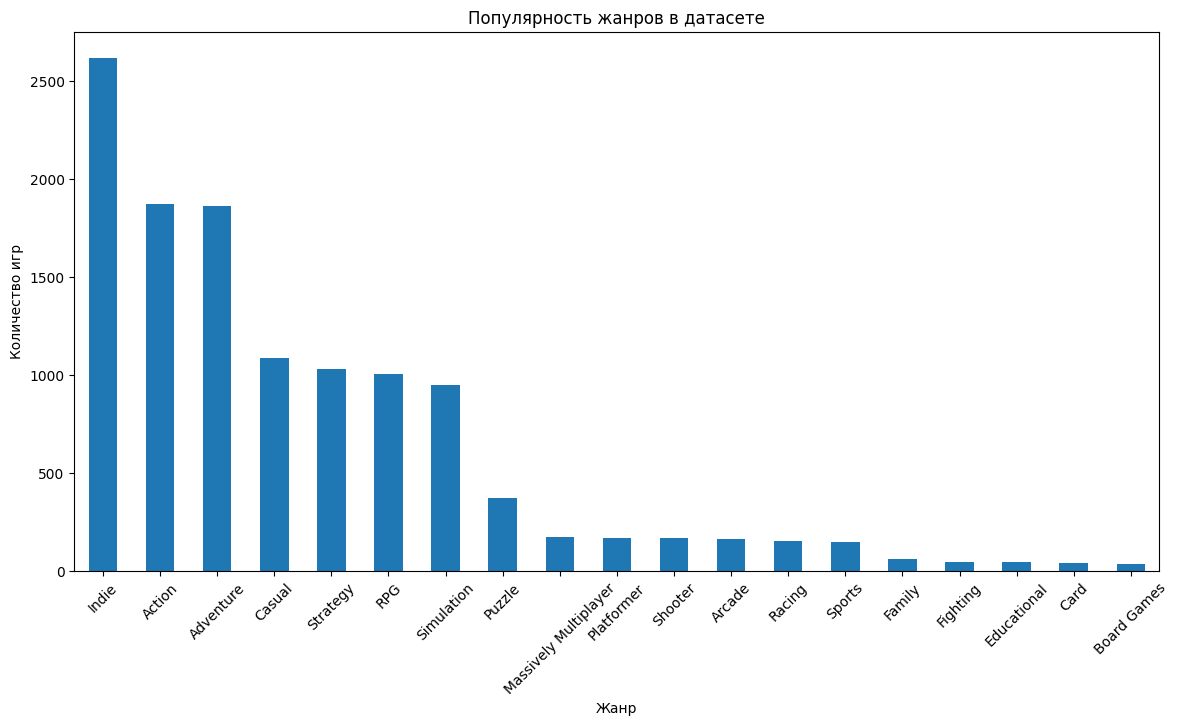

In [ ]:
genres = (df["genres"].dropna().str.split(",").explode().str.strip())

counts = genres.value_counts()

plt.figure(figsize=(14, 7))
counts.plot(kind="bar")

plt.xlabel("Жанр")
plt.ylabel("Количество игр")
plt.title("Популярность жанров в датасете")
plt.xticks(rotation=45)

plt.show()

# Количество топ 7 жанров

In [ ]:
top7 = counts.head(7)
top7.index = top7.index.str.replace("genre_", "")

top7

genres
Indie         2618
Action        1869
Adventure     1860
Casual        1088
Strategy      1031
RPG           1004
Simulation     949
Name: count, dtype: int64

# Топ жанров по количеству

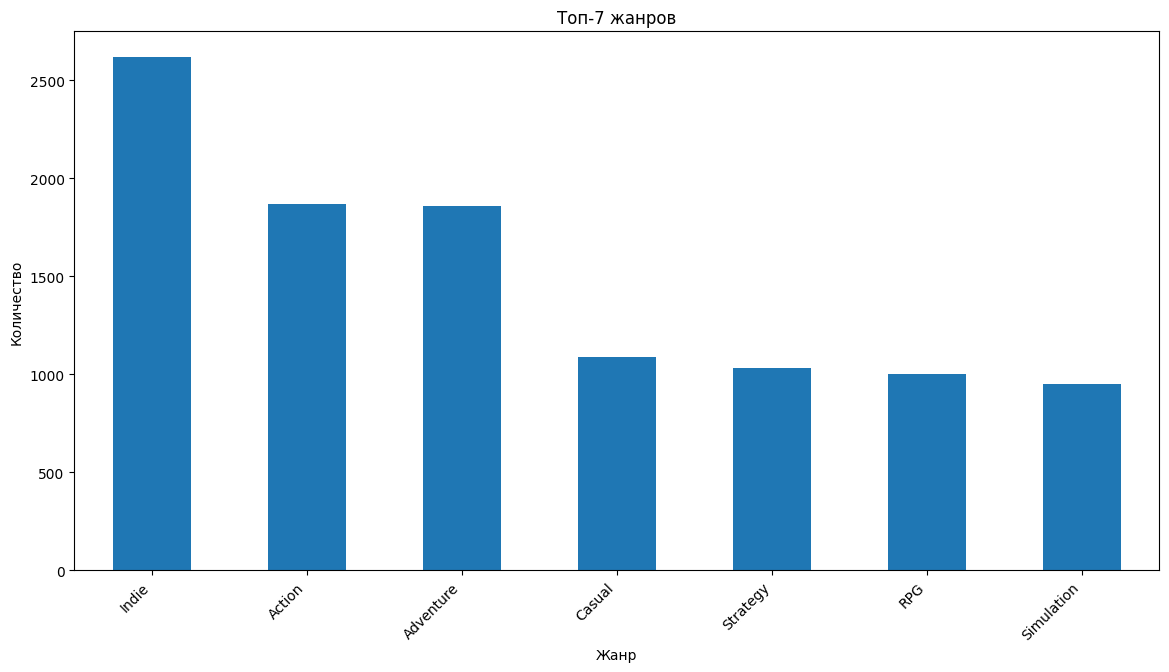

In [ ]:
plt.figure(figsize=(14, 7))
top7.plot(kind="bar")

plt.xlabel("Жанр")
plt.ylabel("Количество")
plt.title("Топ-7 жанров")

plt.xticks(rotation=45, ha="right")
plt.show()

# Цена по жанру

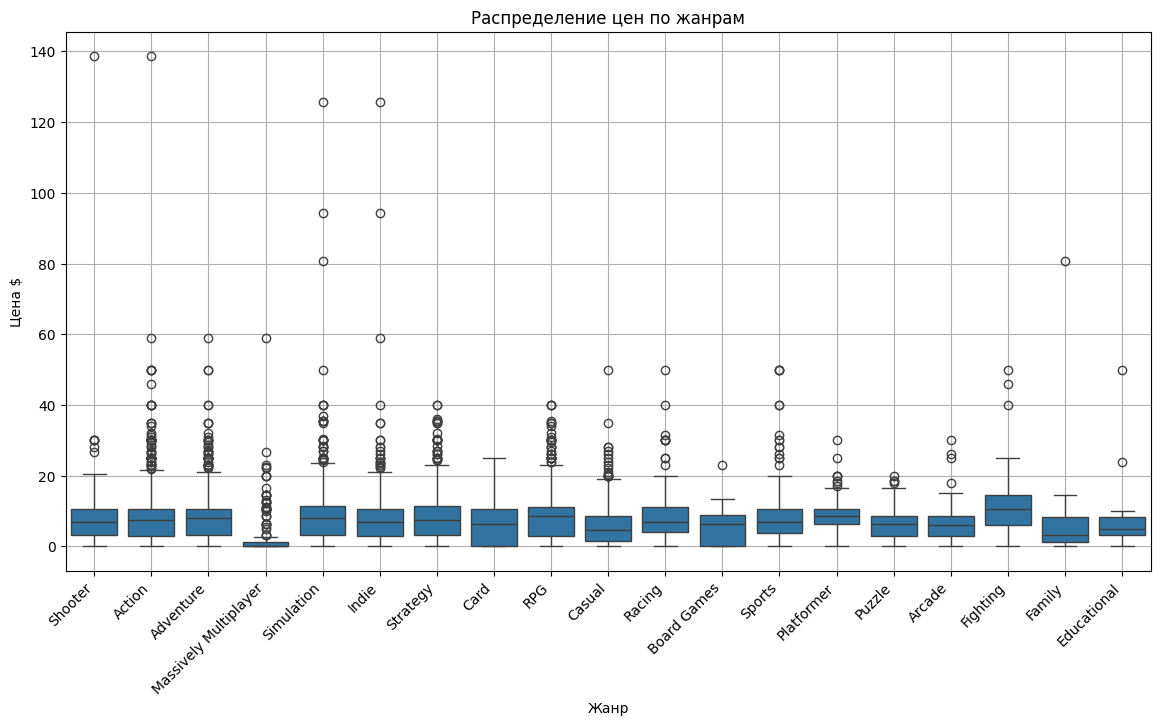

In [ ]:
genres_df = (df[["genres", "price_usd"]].dropna().assign(genres=df["genres"].str.split(",")).explode("genres"))

genres_df["genres"] = genres_df["genres"].str.strip()
genres_df = genres_df[genres_df["genres"].map(genres_df["genres"].value_counts()) >= 30]

plt.figure(figsize=(14, 7))
sns.boxplot(data=genres_df, x="genres", y="price_usd")

plt.xticks(rotation=45, ha="right")
plt.xlabel("Жанр")
plt.ylabel("Цена $")
plt.title("Распределение цен по жанрам")
plt.grid()
plt.show()

График показывает распределение цен внутри каждого жанра. Видно, что большинство жанров имеют схожую медианную цену в низком диапазоне (вероятно, 5–10 $), но некоторые жанры (например, стратегии, симуляторы или экшены) могут демонстрировать более высокий разброс цен и наличие дорогих выбросов. Бесплатные игры (цена 0) присутствуют почти во всех жанрах. Жанры с большим количеством выбросов вверх указывают на наличие премиальных или дорогих релизов. В целом, ценовая структура по жанрам похожа, но отдельные категории выделяются более широким диапазоном цен.

# Какая цена чаще встречается

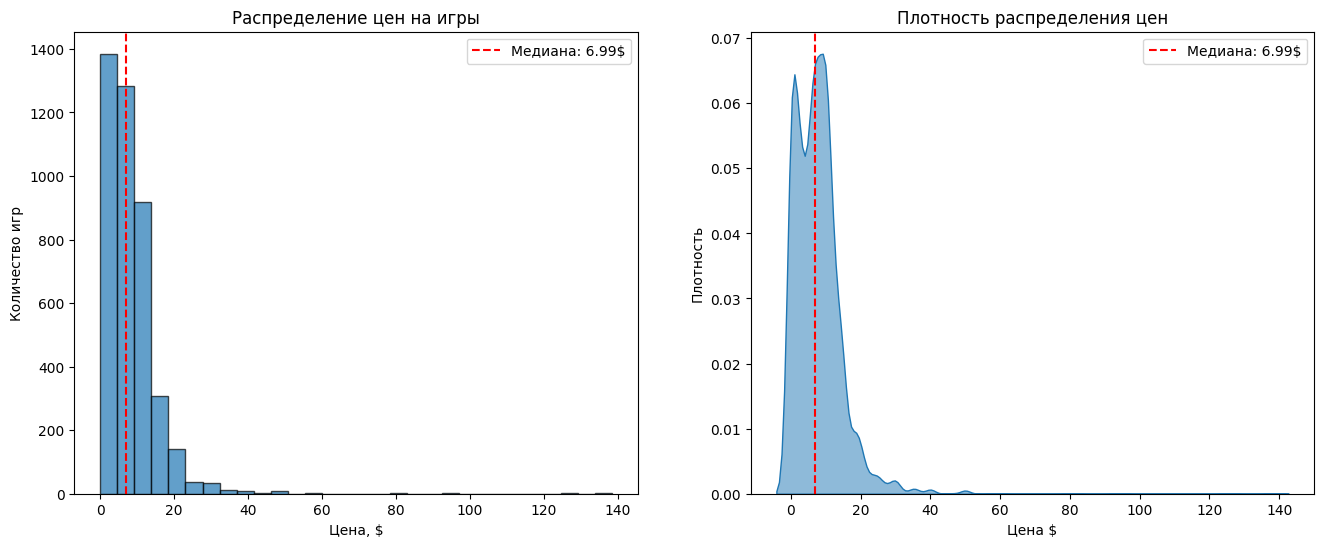

Средняя цена: 7.80
Медианная цена: 6.99


In [ ]:
median_price = df['price_usd'].median()
mean_price = df['price_usd'].mean()

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.hist(df['price_usd'].dropna(), bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Цена, $')
plt.ylabel('Количество игр')
plt.title('Распределение цен на игры')
plt.axvline(median_price, color='red', linestyle='--', label=f'Медиана: {median_price:.2f}$')
plt.legend()

plt.subplot(1, 2, 2)
sns.kdeplot(df['price_usd'].dropna(), fill=True, alpha=0.5)
plt.xlabel('Цена $')
plt.ylabel('Плотность')
plt.title('Плотность распределения цен')
plt.axvline(median_price, color='red', linestyle='--', label=f'Медиана: {median_price:.2f}$')
plt.legend()

plt.show()

print(f'Средняя цена: {mean_price:.2f}')
print(f'Медианная цена: {median_price:.2f}')

# Топ игр по отзывам

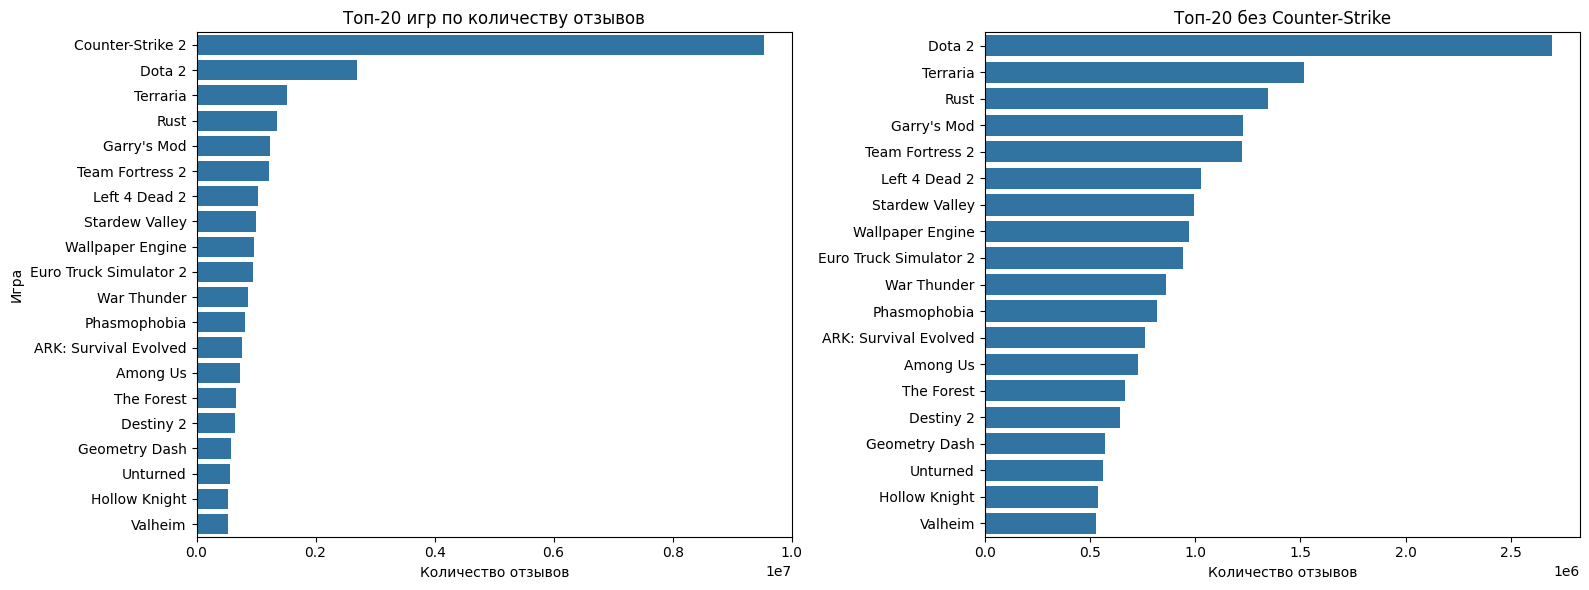

In [ ]:
top_games = df.sort_values("total_reviews", ascending=False).head(20)
top_games_no_cs = top_games[~top_games["name"].str.contains("Counter-Strike")]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_games, x="total_reviews", y="name", ax=axes[0])
axes[0].set_xlabel("Количество отзывов")
axes[0].set_ylabel("Игра")
axes[0].set_title("Топ-20 игр по количеству отзывов")

sns.barplot(data=top_games_no_cs, x="total_reviews", y="name", ax=axes[1])
axes[1].set_xlabel("Количество отзывов")
axes[1].set_ylabel("")
axes[1].set_title("Топ-20 без Counter-Strike")

plt.tight_layout()
plt.show()

Наблюдается сильный разрыв между топ-играми и остальными. Видно невооруженным глазом, что Counter Strike 2 лидирует. Если исключить Counter Strike 2, видно, что следующий лидер Dota 2 (ШОК). Это подтверждает, что рынок работает по принципу - победитель забирает всё!

# Отзывы и рейтинг


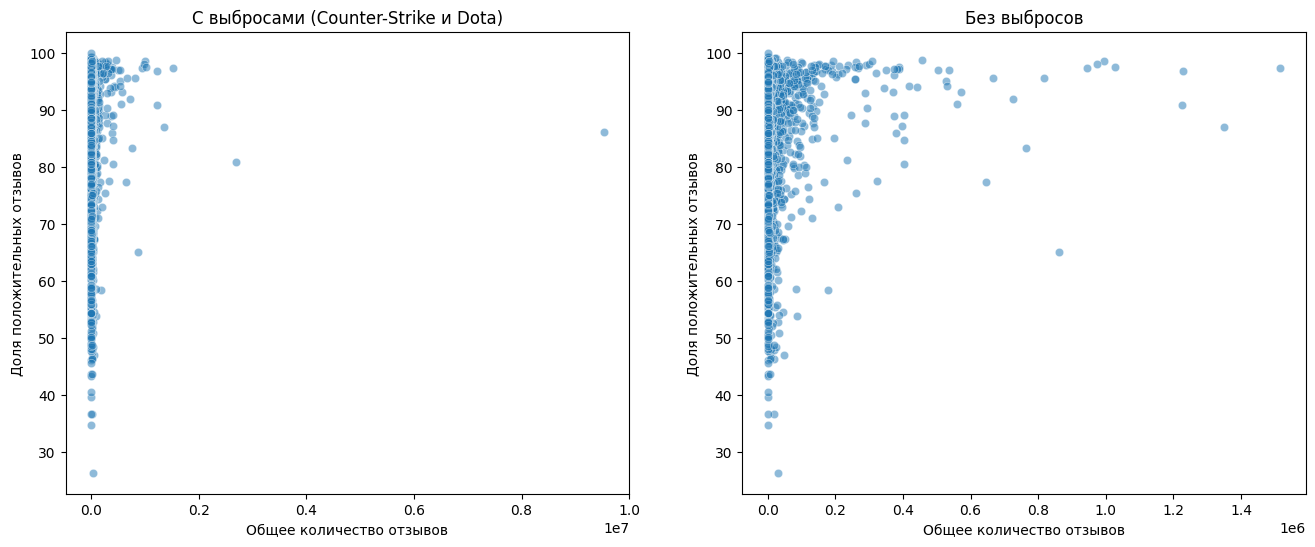

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

df_no_outliers = df[~df["name"].isin(["Counter-Strike 2", "Dota 2"])]

sns.scatterplot(data=df, x="total_reviews", y="positive_ratio", ax=ax1, alpha=0.5)
ax1.set_xlabel("Общее количество отзывов")
ax1.set_ylabel("Доля положительных отзывов")
ax1.set_title("С выбросами (Counter-Strike и Dota)")

sns.scatterplot(data=df_no_outliers, x="total_reviews", y="positive_ratio", ax=ax2, alpha=0.5)
ax2.set_xlabel("Общее количество отзывов")
ax2.set_ylabel("Доля положительных отзывов")
ax2.set_title("Без выбросов")

plt.show()

Анализ распределения количества пользовательских отзывов показывает наличие сильной асимметрии в данных. Небольшое число игр (например, Counter-Strike 2 и Dota 2) значительно превосходит остальные по количеству отзывов и выступает в качестве выбросов. После их исключения становится видно, что большинство игр имеет относительно небольшое количество отзывов, при этом доля положительных отзывов в среднем остаётся высокой.

# Цена и рейтинг

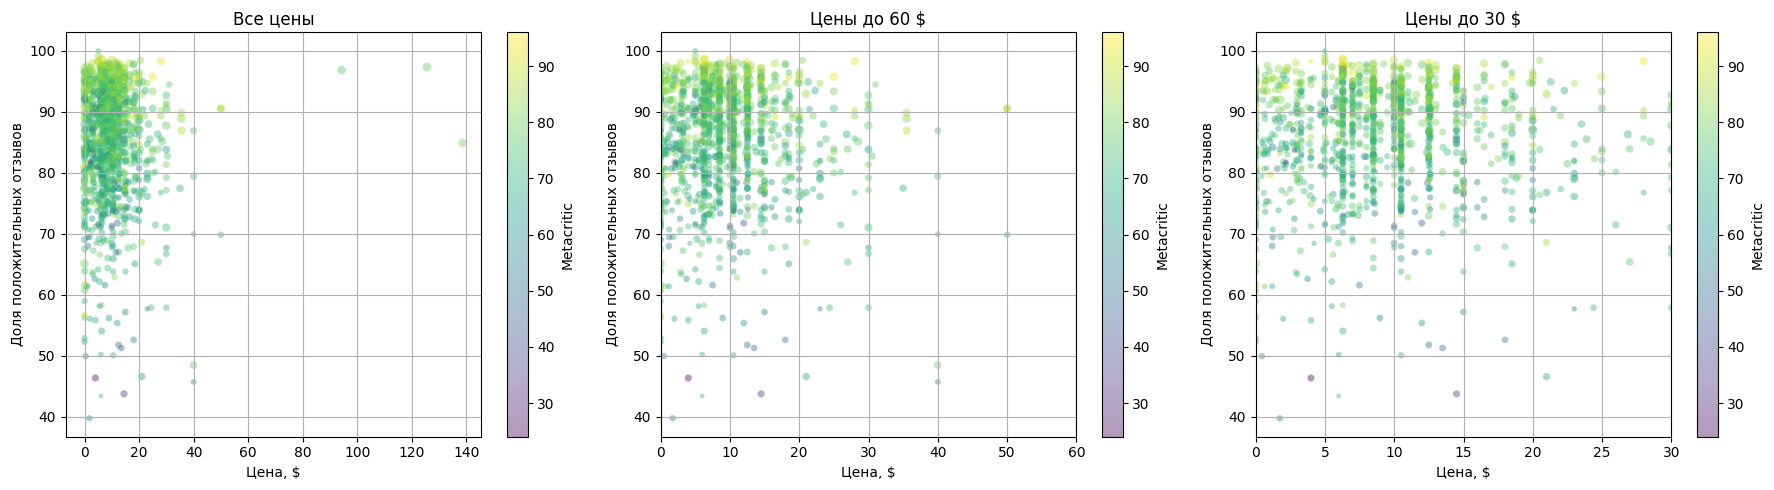

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

limits = [None, 60, 30]
titles = ['Все цены', 'Цены до 60 $', 'Цены до 30 $']

for ax, limit, title in zip(axes, limits, titles):
    data = df if limit is None else df[df['price_usd'] <= limit]
    sizes = np.log1p(data['total_reviews']) * 3

    scatter = ax.scatter(
        data['price_usd'],
        data['positive_ratio'],
        c=data['metacritic'],
        cmap='viridis',
        s=sizes,
        alpha=0.4,
        edgecolors='none')

    ax.set_xlabel('Цена, $')
    ax.set_ylabel('Доля положительных отзывов')
    ax.set_title(title)
    ax.grid()

    if limit is not None:
        ax.set_xlim(0, limit)

    plt.colorbar(scatter, ax=ax, label='Metacritic')

plt.tight_layout()
plt.show()

Анализ показывает, что цена игры не демонстрирует выраженной прямой связи с долей положительных пользовательских отзывов. Основная часть игр сосредоточена в низком и среднем ценовом сегменте, при этом большинство из них получает высокую пользовательскую оценку. Более высокие значения Metacritic чаще наблюдаются у игр с высокой долей положительных отзывов, что указывает на относительную согласованность оценок критиков и игроков. При этом наиболее популярные игры, судя по размеру точек, нередко находятся не в дорогом, а в доступном ценовом сегменте.

# Цена и популярность

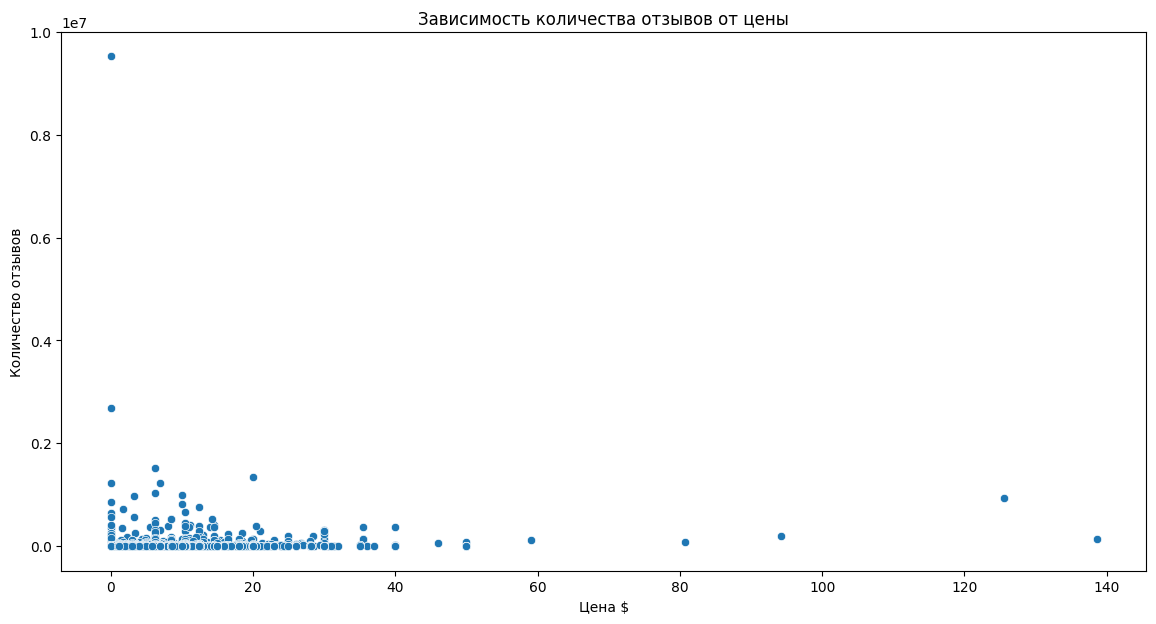

In [ ]:
plt.figure(figsize=(14, 7))

sns.scatterplot(data=df, x="price_usd", y="total_reviews")

plt.xlabel("Цена $")
plt.ylabel("Количество отзывов")
plt.title("Зависимость количества отзывов от цены")

plt.show()

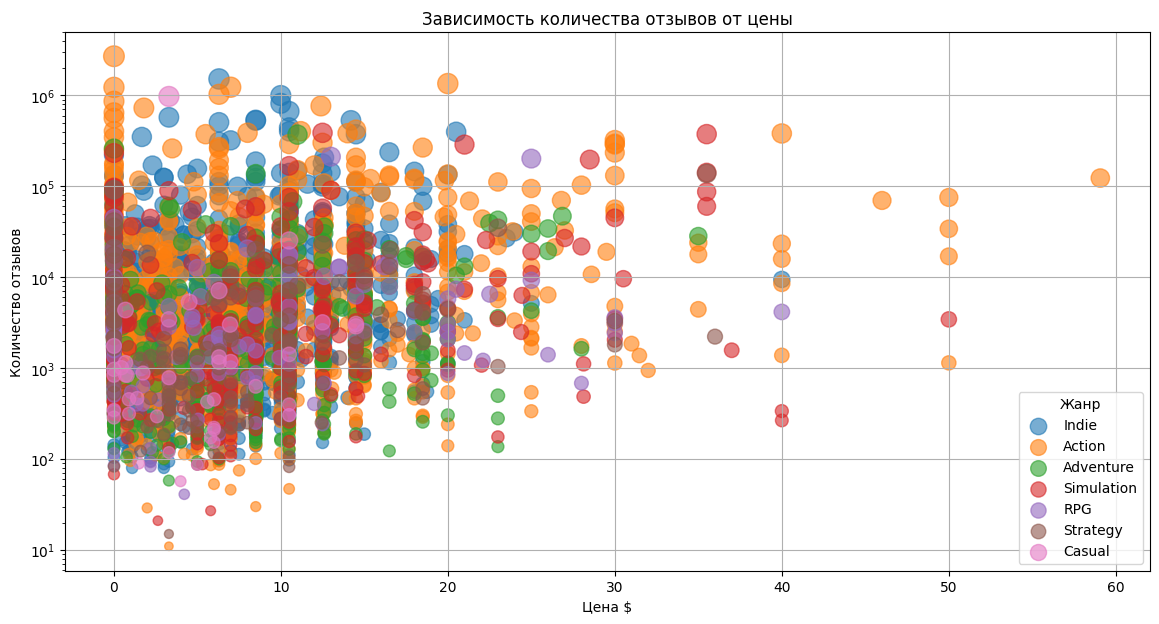

In [ ]:
genres = ['Indie', 'Action', 'Adventure', 'Simulation', 'RPG', 'Strategy', 'Casual']

df['main_genre'] = (
    df[genres]
    .idxmax(axis=1)
    .where(df[genres].sum(axis=1) > 0, 'Other'))

filtered = df[(df['price_usd'] <= 60) & (df['main_genre'].isin(genres))]

plt.figure(figsize=(14, 7))

for genre in genres:
    subset = filtered[filtered['main_genre'] == genre]
    plt.scatter(
        subset['price_usd'],
        subset['total_reviews'],
        s=np.log1p(subset['total_reviews']) * 15,
        alpha=0.6,
        label=genre)

plt.xlabel('Цена $')
plt.ylabel('Количество отзывов')
plt.yscale('log')
plt.title('Зависимость количества отзывов от цены')
plt.legend(title='Жанр')
plt.grid()
plt.show()

Анализ графика показывает, что цена игры не является определяющим фактором её популярности, измеряемой количеством пользовательских отзывов. Большинство игр сосредоточено в доступном ценовом диапазоне до 20 долларов, однако высокое число отзывов может наблюдаться в разных ценовых сегментах. Наиболее популярные проекты чаще встречаются в жанрах Action и Indie, однако внутри каждого жанра сохраняется значительный разброс популярности, что указывает на влияние множества дополнительных факторов.

# Игры по годам

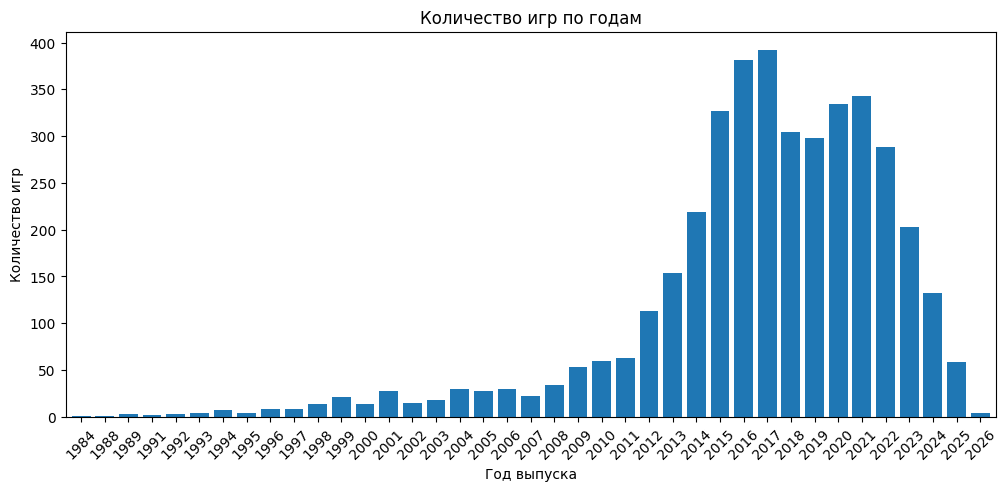

In [ ]:
df["release_year"] = pd.to_datetime(df["released"]).dt.year

games_per_year = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
ax = games_per_year.plot(kind="bar", width=0.8)

ax.set_xlabel("Год выпуска")
ax.set_ylabel("Количество игр")
ax.set_title("Количество игр по годам")

ax.set_xticklabels(games_per_year.index.astype(int), rotation=45)

plt.show()

1980-е: Старт активного роста рынка благодаря удешевлению домашних ПК.
Середина 2000-х: Всплеск благодаря играм вроде GTA и World of Warcraft, а также цифровым сервисам.
 2010-е: Эпоха Minecraft, масштабных RPG и киберспорта, ставшая пиком индустрии.
 2013 (Рост): Выход PS4/Xbox One и релиз-гигант GTA V.
 2016–2018 (Взлет): Бум мобильных телефонов и феномен «королевских битв» (Fortnite, PUBG).
 2019 (Спад): Затишье перед новым поколением консолей и госрегулирование в Китае.
 2021–2022 (Пик): Эффект пандемии — все сидели дома и тратили деньги на игры.
 2023–2024 (Спад): после COVID, инфляция и массовые увольнения в студиях
2026  - не полный год, так как всё ещё длиться

# Платформы

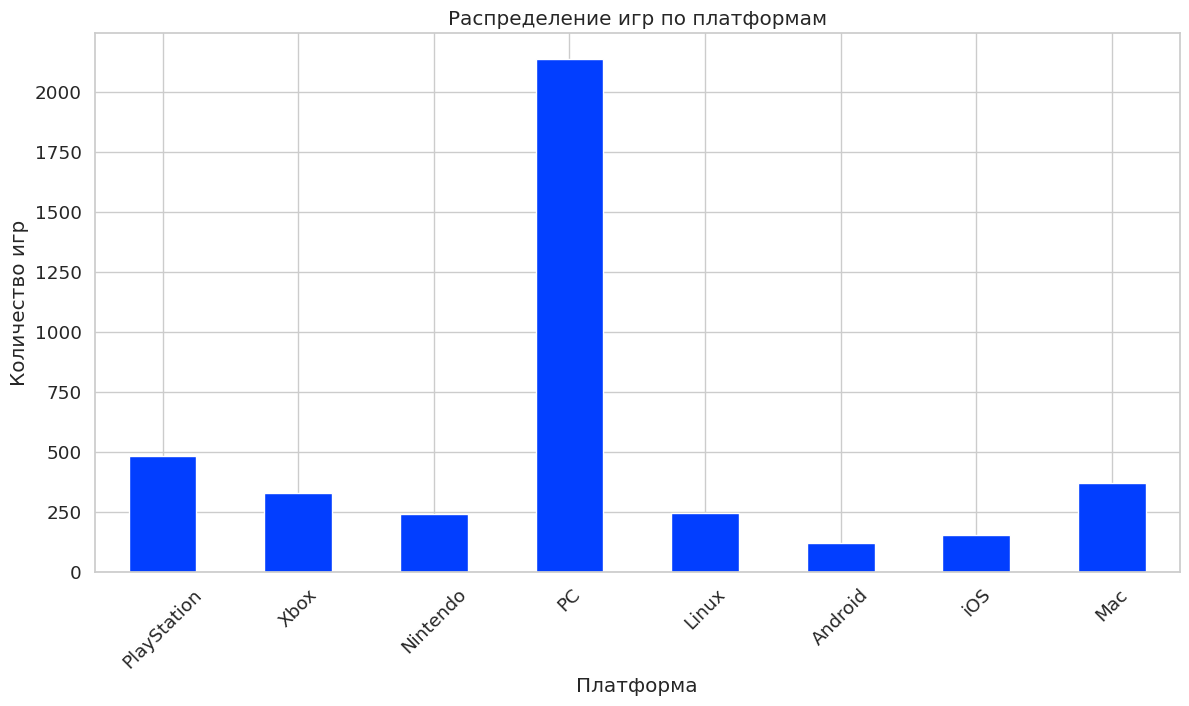

In [ ]:
platforms = ['PlayStation', 'Xbox', 'Nintendo', 'PC', 'Linux', 'Android', 'iOS', 'Mac']

counts = df[platforms].sum()

plt.figure(figsize=(14, 7))
counts.plot(kind='bar')

plt.xlabel('Платформа')
plt.ylabel('Количество игр')
plt.title('Распределение игр по платформам')
plt.xticks(rotation=45)

plt.show()

Анализ распределения игр по платформам показывает, что ПК (PC) является абсолютным лидером, поскольку подавляющее большинство проектов в датасете доступны именно на этой платформе. Среди игровых консолей доминирует PlayStation, за ней следуют Xbox и Nintendo, что отражает их рыночные доли. В то же время мобильные платформы (Android и iOS), а также Linux и Mac представлены значительно меньшим количеством игр, что может быть связано с особенностями выборки или меньшим приоритетом разработки под эти системы. Таким образом, рынок видеоигр в данном датасете сильно ориентирован на PC и основные консоли, в то время как мобильные и нишевые платформы занимают скромную долю

Все платформы:
PC           2137 игр
PlayStation  482 игр
Mac          372 игр
Xbox         331 игр
Linux        246 игр
Nintendo     244 игр
iOS          156 игр
Android      121 игр


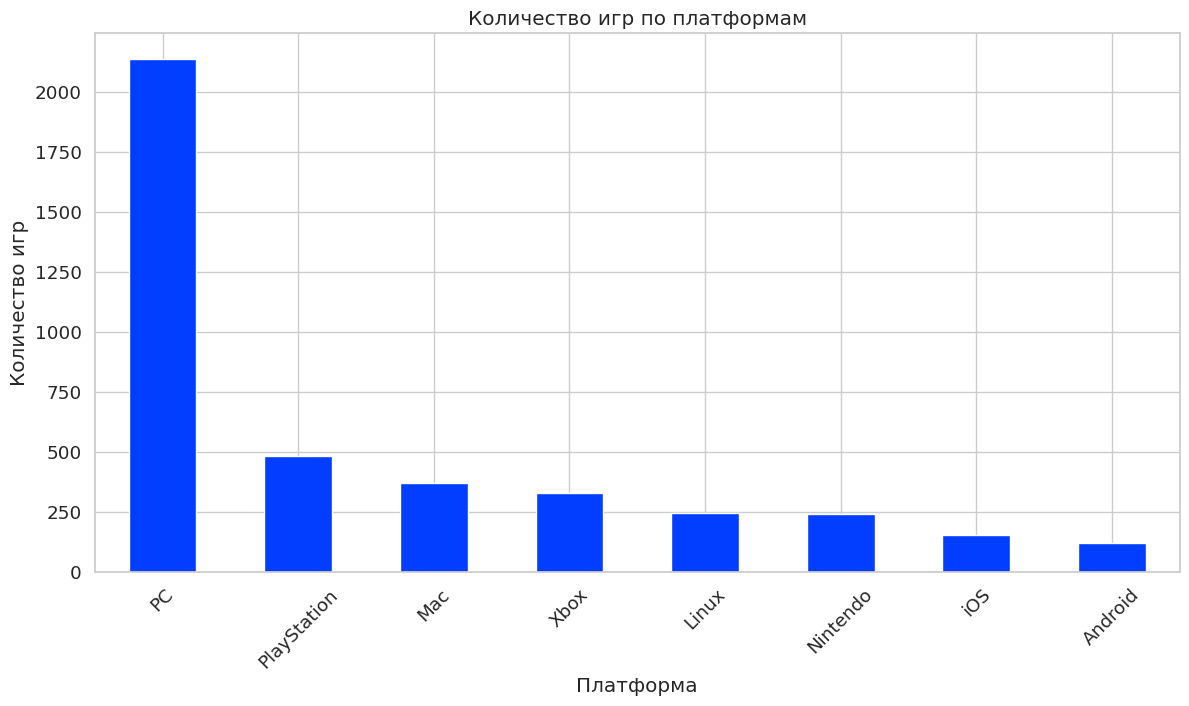

In [ ]:
all_platforms = ['PlayStation', 'Xbox', 'Nintendo', 'Mac', 'PC', 'Linux', 'Android', 'iOS']

platform_counts = df[all_platforms].sum().sort_values(ascending=False)

print("Все платформы:")
for platform, count in platform_counts.items():
    print(f"{platform:12} {int(count)} игр")

plt.figure(figsize=(14, 7))
platform_counts.plot(kind='bar')
plt.title('Количество игр по платформам')
plt.xlabel('Платформа')
plt.ylabel('Количество игр')
plt.xticks(rotation=45)
plt.show()

Платформа Windows доминирует. Это подтверждает, что основной рынок — PC

# Распределение положительных отзывов по платформам

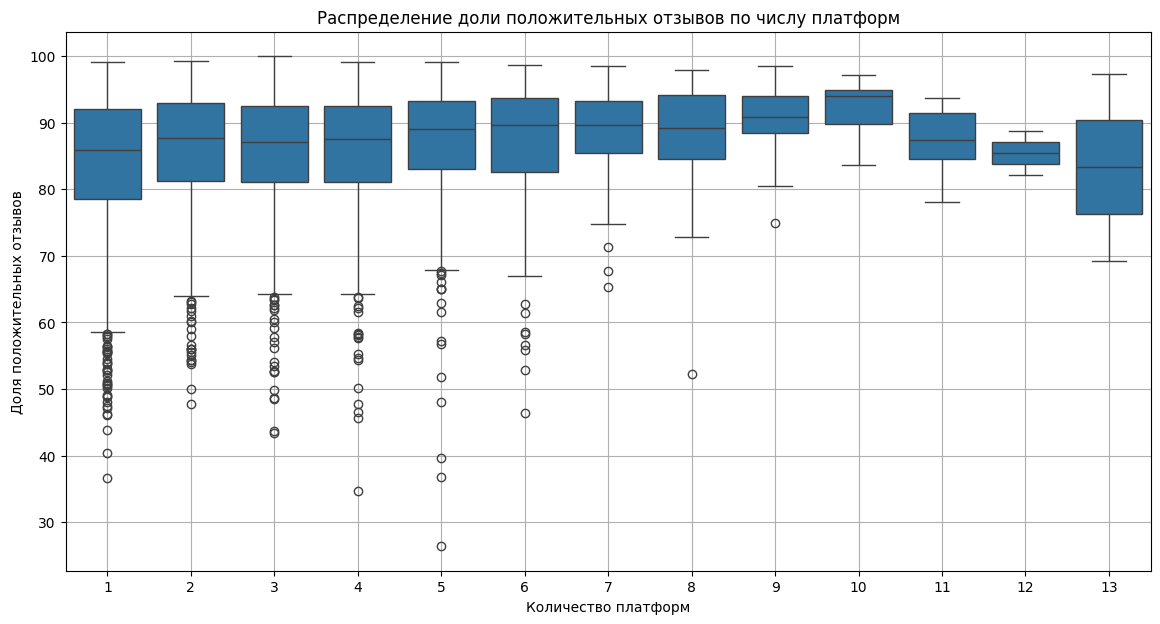

In [ ]:
plot_df = df.dropna(subset=["platform_count", "positive_ratio"])

plt.figure(figsize=(14, 7))
sns.boxplot(data=plot_df, x="platform_count", y="positive_ratio")
plt.title("Распределение доли положительных отзывов по числу платформ")
plt.xlabel("Количество платформ")
plt.ylabel("Доля положительных отзывов")
plt.grid()
plt.show()

# Игровое время и жанры

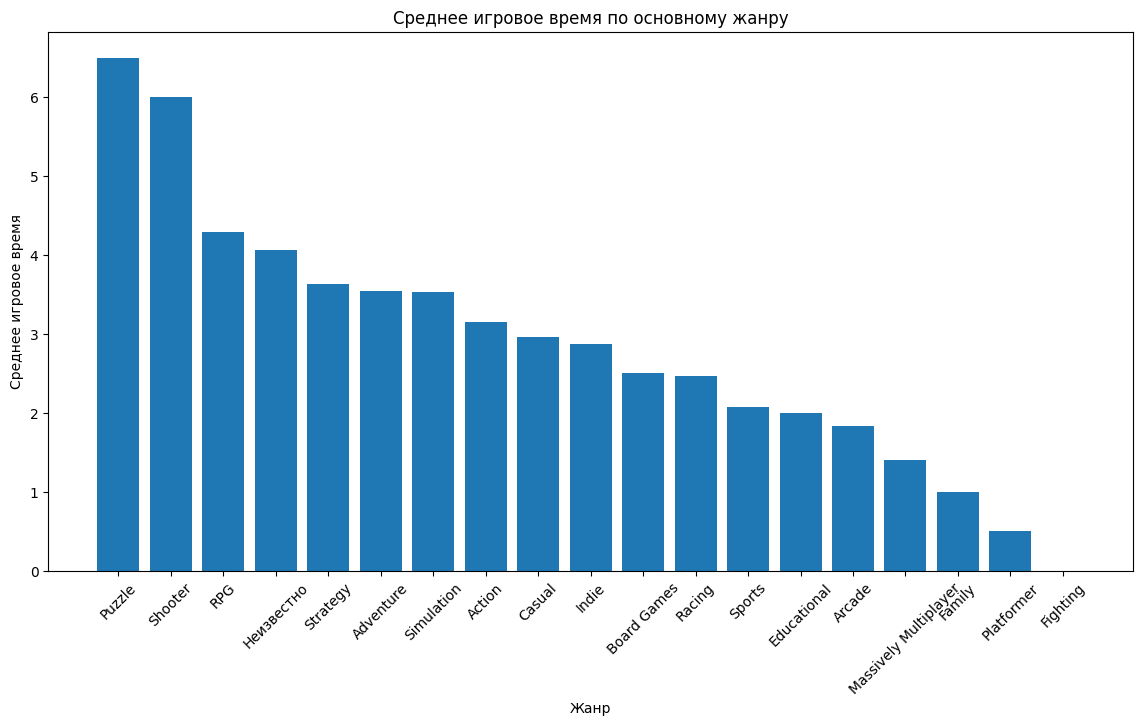

In [ ]:
df["main_genre"] = df["genres"].fillna("Неизвестно").str.split(",").str[0].str.strip()

genre_playtime = df.groupby("main_genre")["playtime"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 7))
plt.bar(genre_playtime.index, genre_playtime.values)

plt.xlabel("Жанр")
plt.ylabel("Среднее игровое время")
plt.title("Среднее игровое время по основному жанру")
plt.xticks(rotation=45)

plt.show()

Игры с большим временем прохождения часто получают более высокие оценки — пользователи ценят “ценность за деньги”

# Корреляция

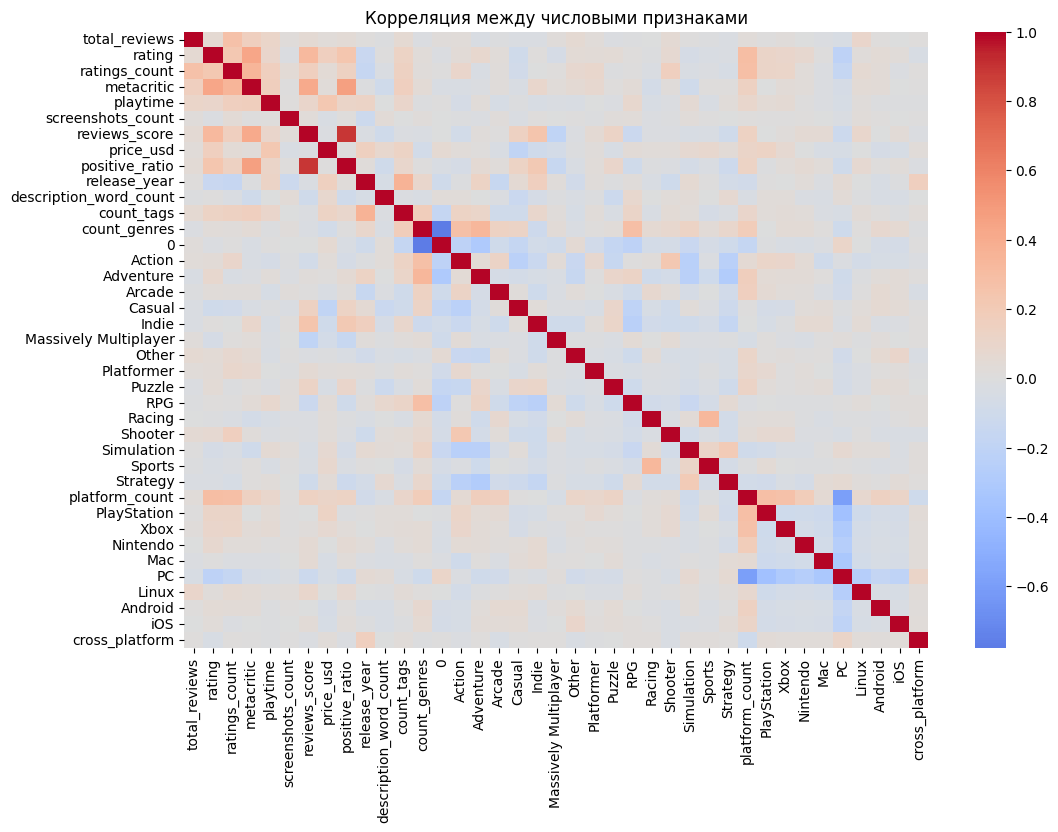

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm', center=0)
plt.title('Корреляция между числовыми признаками')
plt.show()

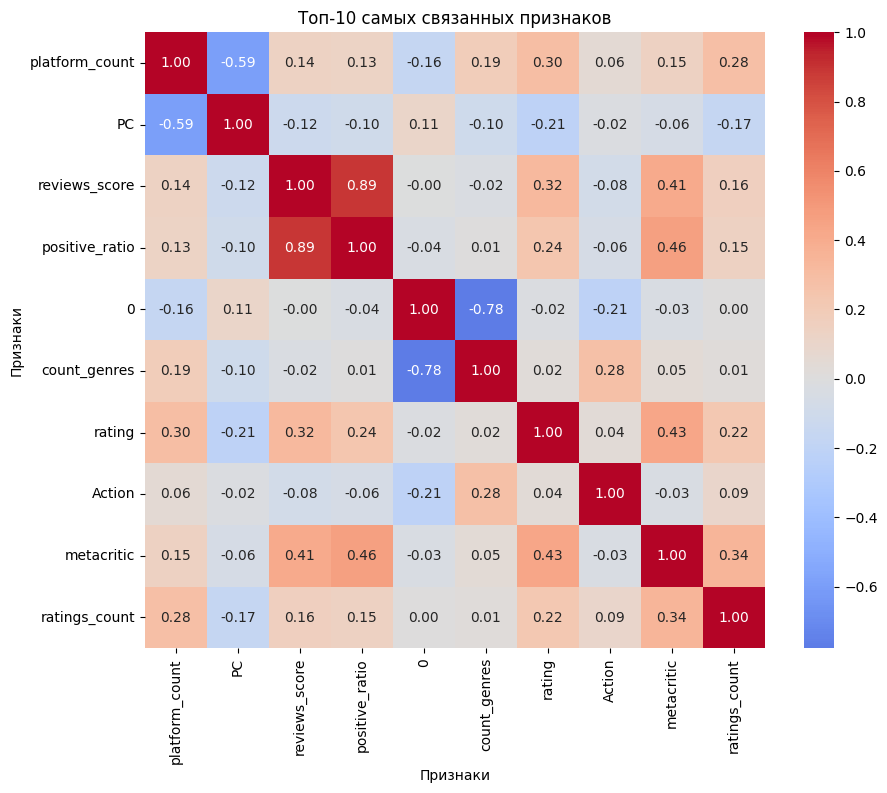

In [ ]:
corr_matrix = df.corr(numeric_only=True)
top_features = corr_matrix.abs().sum().sort_values(ascending=False).head(10).index

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix.loc[top_features, top_features],
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0)

plt.title("Топ-10 самых связанных признаков")
plt.xlabel("Признаки")
plt.ylabel("Признаки")
plt.show()

Код выделяет из датафрейма только числовые признаки, вычисляет матрицу корреляций между ними, затем отбирает 10 признаков с наибольшей суммарной корреляцией с остальными (по абсолютному значению). После этого строится тепловая карта, показывающая попарные корреляции только между этими топ-10 признаками, с цветовой шкалой от синего (отрицательная корреляция) до красного (положительная).

Что позволяет увидеть визуализация:

Какие признаки из топ-10 наиболее сильно связаны друг с другом.
Направление связи (положительная или отрицательная).
Сильные и слабые корреляционные связи в этой группе.